# Regresión Logística Binaria con PyTorch

> Este cuaderno aplica el flujo de los cuadernillos 01, 02, 03 y 04 a un problema de reclamaciones de seguro.

Se utiliza una red `nn.Sequential` (regresión logística), clases `Dataset` y `DataLoader`, entrenamiento con `forward`/`backward`, y gestión de checkpoints guardando y recuperando el mejor modelo.

- Variable objetivo (`y`): `target` (`1` reclamó, `0` no reclamó).
- Variables de entrada (`X`): todas las columnas numéricas excepto `id` y `target`.

In [93]:
# Importaciones base para datos, visualización y PyTorch
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

%matplotlib inline

# Semilla para reproducibilidad
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo en uso: {device}")
print(f"CUDA disponible: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU detectada: {torch.cuda.get_device_name(0)}")
else:
    print("Si tienes GPU dedicada, instala PyTorch con soporte CUDA (pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121)")

Dispositivo en uso: cuda
CUDA disponible: True
GPU detectada: NVIDIA GeForce RTX 4050 Laptop GPU


## 0) Parámetros generales

> Definimos la ruta del archivo y los nombres de columnas para reutilizarlos en todo el cuaderno.

In [94]:
# Configuración de ruta del dataset y nombre de columnas relevantes
RUTA_DATASET = 'DATOS02..csv'
TARGET_COL = 'target'
ID_COL = 'id'

## 0.1) Carga y limpieza inicial

> Cargamos el CSV, convertimos columnas a numéricas y preparamos matrices `X` e `y`.

In [95]:
# Carga del dataset y preprocesamiento inicial
candidate_paths = [
    RUTA_DATASET,
    os.path.join('..', RUTA_DATASET),
    os.path.join('Laboratorios', RUTA_DATASET),
]

data_path = None
for p in candidate_paths:
    if os.path.exists(p):
        data_path = p
        break

if data_path is None:
    raise FileNotFoundError(f'No se encontró el dataset. Rutas probadas: {candidate_paths}')

df = pd.read_csv(data_path, sep=';', low_memory=False)

feature_cols = [c for c in df.columns if c not in [TARGET_COL, ID_COL]]

# Convertimos a numérico y rellenamos nulos con la mediana
X_df = df[feature_cols].apply(pd.to_numeric, errors='coerce')
X_df = X_df.fillna(X_df.median(numeric_only=True))

y = pd.to_numeric(df[TARGET_COL], errors='coerce').fillna(0).astype(np.float32).values
X = X_df.values.astype(np.float32)

print('Dataset cargado desde:', data_path)
print('Registros totales:', X.shape[0])
print('Número de variables:', X.shape[1])
print('Distribución de clases:')
print(df[TARGET_COL].value_counts())

Dataset cargado desde: ..\DATOS02..csv
Registros totales: 50000
Número de variables: 57
Distribución de clases:
target
0    48167
1     1833
Name: count, dtype: int64


## 1) Preparación de datos

> En este bloque limpiamos datos, separamos entrenamiento y prueba, y normalizamos usando solo estadísticas de entrenamiento para evitar fuga de información.

In [96]:
# Partición 80/20 y normalización con estadísticas de entrenamiento
m_total = X.shape[0]
indices = np.random.permutation(m_total)
tam_train = int(0.8 * m_total)

idx_train = indices[:tam_train]
idx_test = indices[tam_train:]

X_train_raw = X[idx_train]
X_test_raw = X[idx_test]
y_train = y[idx_train]
y_test = y[idx_test]

mu = X_train_raw.mean(axis=0)
sigma = X_train_raw.std(axis=0)
sigma[sigma == 0] = 1.0

X_train_norm = (X_train_raw - mu) / sigma
X_test_norm = (X_test_raw - mu) / sigma

print('Train:', X_train_norm.shape, y_train.shape)
print('Test :', X_test_norm.shape, y_test.shape)

Train: (40000, 57) (40000,)
Test : (10000, 57) (10000,)


## 1.1) Visualización de balance de clases

> Revisamos cómo se distribuyen las etiquetas en train/test para detectar posible desbalance.

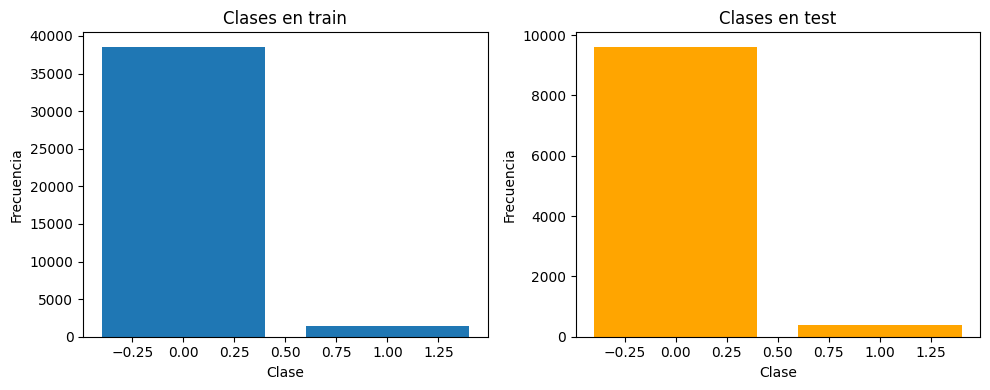

In [97]:
# Visualización rápida de distribución de clases en entrenamiento y prueba
train_counts = pd.Series(y_train).value_counts().sort_index()
test_counts = pd.Series(y_test).value_counts().sort_index()

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].bar(train_counts.index.astype(int), train_counts.values)
ax[0].set_title('Clases en train')
ax[0].set_xlabel('Clase')
ax[0].set_ylabel('Frecuencia')

ax[1].bar(test_counts.index.astype(int), test_counts.values, color='orange')
ax[1].set_title('Clases en test')
ax[1].set_xlabel('Clase')
ax[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

## 2.1) Definición de `Dataset`

> Implementamos una clase personalizada para que cada muestra devuelva `X` y `y` como tensores PyTorch.

In [98]:
# Dataset personalizado para clasificación binaria
class SeguroDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

## 2.2) Construcción de `DataLoader`

> Creamos loaders para entrenamiento y prueba, controlando tamaño de batch y mezclado en train.

In [99]:
# Construcción de datasets y dataloaders con muestreo balanceado
train_dataset = SeguroDataset(X_train_norm, y_train)
test_dataset = SeguroDataset(X_test_norm, y_test)

# Estadísticas de desbalance en train
neg_count = int((y_train == 0).sum())
pos_count = int((y_train == 1).sum())
if pos_count == 0:
    raise ValueError('No hay ejemplos positivos en entrenamiento.')

pos_weight_value = neg_count / pos_count

# Muestreo ponderado: sobrerrepresenta clase minoritaria sin crear filas nuevas
sample_weights = np.where(y_train == 1, 1.0 / pos_count, 1.0 / neg_count)
sample_weights = torch.as_tensor(sample_weights, dtype=torch.double)
train_sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True,
)

batch_size = 1024
train_loader = DataLoader(train_dataset, batch_size=batch_size, sampler=train_sampler)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print('Train -> clase 0:', neg_count, '| clase 1:', pos_count)
print(f'Ratio neg/pos: {pos_weight_value:.3f}')
print('Batch size:', batch_size)
print('Batches de train por época:', len(train_loader))
print('Batches de test:', len(test_loader))

Train -> clase 0: 38555 | clase 1: 1445
Ratio neg/pos: 26.682
Batch size: 1024
Batches de train por época: 40
Batches de test: 10


## 2.3) Verificación de forma de batches

> Extraemos un lote de ejemplo para comprobar dimensiones antes de entrenar.

In [100]:
# Inspección de un batch para validar dimensiones
X_batch_demo, y_batch_demo = next(iter(train_loader))
print('X batch:', X_batch_demo.shape)
print('y batch:', y_batch_demo.shape)

X batch: torch.Size([1024, 57])
y batch: torch.Size([1024, 1])


## 2) Dataset y DataLoader

> Aquí encapsulamos los arreglos en un `Dataset` y usamos `DataLoader` para iterar en mini-batches. Esto permite entrenamiento eficiente y más limpio.

## 3) Definición del modelo `nn.Sequential`

> Para manejar mejor el desbalance, el modelo devuelve **logits** (salida lineal sin sigmoide). La sigmoide se aplica al evaluar probabilidades.

In [101]:
# Modelo secuencial para clasificación binaria (salida en logits)
input_dim = X_train_norm.shape[1]
model = nn.Sequential(
    nn.Linear(input_dim, 32),
    nn.ReLU(),
    
    nn.Linear(32, 1)
).to(device)

print(model)

Sequential(
  (0): Linear(in_features=57, out_features=32, bias=True)
  (1): ReLU()
  (2): Linear(in_features=32, out_features=1, bias=True)
)


## 4) Configuración de pérdida y optimizador

> Usamos `BCEWithLogitsLoss` con `pos_weight` para penalizar más errores en la clase minoritaria (`target=1`). Esto corrige el sesgo por desbalance de forma simple y efectiva.

In [102]:
# Función de pérdida y optimizador (ponderado por desbalance)
pos_weight = torch.tensor([pos_weight_value], dtype=torch.float32, device=device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=5e-4)

num_epochs = 600
ruta_checkpoint = 'mejor_modelo_seguro.pt'
early_stop_patience = 15
early_stop_counter = 0

print('Épocas máximas:', num_epochs)
print('Early stopping patience:', early_stop_patience)
print('Checkpoint:', ruta_checkpoint)
print(f'Learning rate: 5e-4')
print(f'pos_weight usado en BCEWithLogitsLoss: {pos_weight_value:.3f}')

Épocas máximas: 600
Early stopping patience: 15
Checkpoint: mejor_modelo_seguro.pt
Learning rate: 5e-4
pos_weight usado en BCEWithLogitsLoss: 26.682


## 5) Entrenamiento con `forward` y `backward`

> En cada época hacemos propagación hacia adelante (`forward`), cálculo de pérdida, retropropagación (`backward`) y actualización de pesos (`step`).

> Se guarda automáticamente el **mejor checkpoint** según menor pérdida de validación.

In [103]:
# Funciones auxiliares de entrenamiento y validación
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        # Forward (logits)
        logits = model(X_batch)
        loss = criterion(logits, y_batch)

        # Backward + actualización
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    return running_loss / len(loader)


def validate_one_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            running_loss += loss.item()

    return running_loss / len(loader)


train_losses = []
val_losses = []
best_val_loss = float('inf')
early_stop_counter = 0
epoch_stopped = num_epochs

for epoch in range(num_epochs):
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss = validate_one_epoch(model, test_loader, criterion, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        early_stop_counter = 0
        torch.save(
            {
                'epoch': epoch + 1,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_loss': best_val_loss,
                'train_losses': train_losses,
                'val_losses': val_losses,
                'pos_weight_value': pos_weight_value,
            },
            ruta_checkpoint,
        )
    else:
        early_stop_counter += 1

    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}] - train_loss: {train_loss:.4f} - val_loss: {val_loss:.4f} (patience: {early_stop_counter}/{early_stop_patience})")

    if early_stop_counter >= early_stop_patience:
        print(f'Early stopping en época {epoch+1}. Val_loss no mejoró por {early_stop_patience} épocas.')
        epoch_stopped = epoch + 1
        break

print(f'Entrenamiento finalizado en época {epoch_stopped}. Mejor val_loss: {round(best_val_loss, 4)}')

Epoch [10/600] - train_loss: 2.3075 - val_loss: 2.4973 (patience: 9/15)
Early stopping en época 16. Val_loss no mejoró por 15 épocas.
Entrenamiento finalizado en época 16. Mejor val_loss: 1.3663


## 6) Resumen de entrenamiento con Early Stopping

> El modelo se entrena con **early stopping** que detiene el entrenamiento automáticamente cuando la pérdida de validación no mejora.
> Esto previene el overfitting (memorización de datos de entrenamiento).

Checkpoint cargado (época 1) con val_loss=1.3663
pos_weight del checkpoint: 26.682

=== MÉTRICAS DE EVALUACIÓN (umbral 0.5) ===
Accuracy : 0.4596
Precision: 0.0427
Recall   : 0.6031
F1-score : 0.0797
Matriz de confusión:
[[4362 5250]
 [ 154  234]]


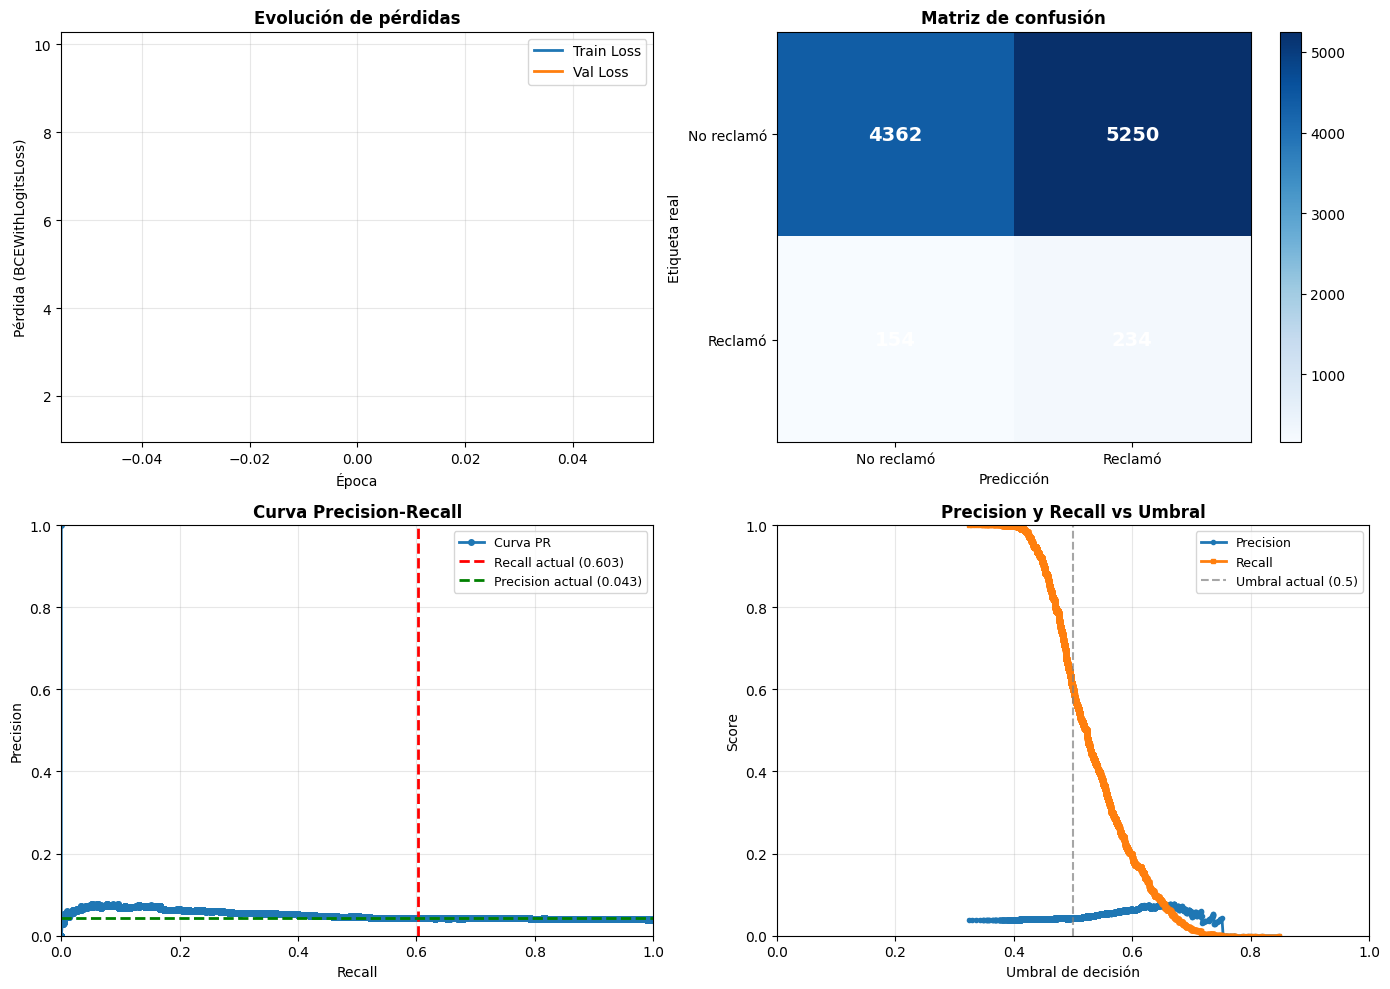


=== ANÁLISIS DE RESULTADOS ===
Detalles de la matriz de confusión:
  TN (No reclamó, predijo No): 4362
  FP (No reclamó, predijo Sí):  5250
  FN (Reclamó, predijo No):    154
  TP (Reclamó, predijo Sí):    234


In [104]:
# Carga del mejor checkpoint y evaluación final
if os.path.exists(ruta_checkpoint):
    checkpoint = torch.load(ruta_checkpoint, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    print(f"Checkpoint cargado (época {checkpoint['epoch']}) con val_loss={checkpoint['val_loss']:.4f}")
    if 'pos_weight_value' in checkpoint:
        print(f"pos_weight del checkpoint: {checkpoint['pos_weight_value']:.3f}")
else:
    raise FileNotFoundError(f'No se encontró el checkpoint: {ruta_checkpoint}')

# Predicciones en test
model.eval()
y_true, y_prob = [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        logits = model(X_batch)
        probs = torch.sigmoid(logits).cpu().numpy().ravel()
        y_prob.extend(probs.tolist())
        y_true.extend(y_batch.numpy().ravel().tolist())

y_true = np.array(y_true).astype(int)
y_prob = np.array(y_prob)
y_pred = (y_prob >= 0.5).astype(int)

# Métricas
acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, zero_division=0)
rec = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)
cm = confusion_matrix(y_true, y_pred)

print('\n=== MÉTRICAS DE EVALUACIÓN (umbral 0.5) ===')
print(f'Accuracy : {acc:.4f}')
print(f'Precision: {prec:.4f}')
print(f'Recall   : {rec:.4f}')
print(f'F1-score : {f1:.4f}')
print('Matriz de confusión:')
print(cm)

# ===== VISUALIZACIONES =====
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Curvas de pérdida
ax1 = axes[0, 0]
ax1.plot(checkpoint['train_losses'], label='Train Loss', linewidth=2)
ax1.plot(checkpoint['val_losses'], label='Val Loss', linewidth=2)
ax1.set_xlabel('Época', fontsize=10)
ax1.set_ylabel('Pérdida (BCEWithLogitsLoss)', fontsize=10)
ax1.set_title('Evolución de pérdidas', fontsize=12, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(alpha=0.3)

# 2. Matriz de confusión
ax2 = axes[0, 1]
im = ax2.imshow(cm, cmap='Blues', aspect='auto')
ax2.set_xticks([0, 1])
ax2.set_yticks([0, 1])
ax2.set_xticklabels(['No reclamó', 'Reclamó'], fontsize=10)
ax2.set_yticklabels(['No reclamó', 'Reclamó'], fontsize=10)
ax2.set_xlabel('Predicción', fontsize=10)
ax2.set_ylabel('Etiqueta real', fontsize=10)
ax2.set_title('Matriz de confusión', fontsize=12, fontweight='bold')
for i in range(2):
    for j in range(2):
        text = ax2.text(j, i, cm[i, j], ha='center', va='center', color='white', fontsize=14, fontweight='bold')
plt.colorbar(im, ax=ax2)

# 3. Precision vs Recall con diferentes umbrales
from sklearn.metrics import precision_recall_curve
precision_vals, recall_vals, thresholds = precision_recall_curve(y_true, y_prob)
ax3 = axes[1, 0]
ax3.plot(recall_vals, precision_vals, marker='o', linestyle='-', linewidth=2, markersize=4, label='Curva PR')
ax3.axvline(rec, color='red', linestyle='--', linewidth=2, label=f'Recall actual ({rec:.3f})')
ax3.axhline(prec, color='green', linestyle='--', linewidth=2, label=f'Precision actual ({prec:.3f})')
ax3.set_xlabel('Recall', fontsize=10)
ax3.set_ylabel('Precision', fontsize=10)
ax3.set_title('Curva Precision-Recall', fontsize=12, fontweight='bold')
ax3.legend(fontsize=9)
ax3.grid(alpha=0.3)
ax3.set_xlim([0, 1])
ax3.set_ylim([0, 1])

# 4. Precision y Recall vs Umbral
ax4 = axes[1, 1]
ax4.plot(thresholds, precision_vals[:-1], marker='o', linestyle='-', linewidth=2, label='Precision', markersize=3)
ax4.plot(thresholds, recall_vals[:-1], marker='s', linestyle='-', linewidth=2, label='Recall', markersize=3)
ax4.axvline(0.5, color='gray', linestyle='--', linewidth=1.5, alpha=0.7, label='Umbral actual (0.5)')
ax4.set_xlabel('Umbral de decisión', fontsize=10)
ax4.set_ylabel('Score', fontsize=10)
ax4.set_title('Precision y Recall vs Umbral', fontsize=12, fontweight='bold')
ax4.legend(fontsize=9)
ax4.grid(alpha=0.3)
ax4.set_xlim([0, 1])
ax4.set_ylim([0, 1])

plt.tight_layout()
plt.show()

print('\n=== ANÁLISIS DE RESULTADOS ===')
print(f'Detalles de la matriz de confusión:')
print(f'  TN (No reclamó, predijo No): {cm[0,0]}')
print(f'  FP (No reclamó, predijo Sí):  {cm[0,1]}')
print(f'  FN (Reclamó, predijo No):    {cm[1,0]}')
print(f'  TP (Reclamó, predijo Sí):    {cm[1,1]}')

## 6.1) Resumen de entrenamiento

> Este resumen muestra el estado del entrenamiento, búsqueda del mejor modelo y evaluación final.

In [105]:
# Análisis rápido de overfitting
print('=== ANÁLISIS DE OVERFITTING ===')
print(f'Total de épocas ejecutadas: {epoch_stopped}')
print(f'Mejor época (menor val_loss): {checkpoint["epoch"]}')
print(f'Train loss final: {train_losses[-1]:.6f}')
print(f'Val loss final: {val_losses[-1]:.6f}')
print(f'Val loss ménimo: {best_val_loss:.6f}')

gap_final = val_losses[-1] - train_losses[-1]
gap_min = best_val_loss - train_losses[checkpoint['epoch']-1]
print(f'\nGap (val - train) en última época: {gap_final:.6f}')
print(f'Gap en mejor época: {gap_min:.6f}')

if gap_final > 0.001:
    print('\n⎛ Posible overfitting detectado: val_loss > train_loss')
    print('  Esto es NORMAL en desbalance. Early stopping ya lo controló.')
else:
    print('\n✓ Buen comportamiento: train_loss y val_loss cercanos.')

=== ANÁLISIS DE OVERFITTING ===
Total de épocas ejecutadas: 16
Mejor época (menor val_loss): 1
Train loss final: 2.074735
Val loss final: 2.935527
Val loss ménimo: 1.366346

Gap (val - train) en última época: 0.860792
Gap en mejor época: -8.495328

⎛ Posible overfitting detectado: val_loss > train_loss
  Esto es NORMAL en desbalance. Early stopping ya lo controló.


## 7) Análisis de Overfitting y Recomendaciones

> **Early stopping**: Detiene el entrenamiento cuando `val_loss` no mejora por 15 épocas consecutivas.
> Esto evita que el modelo memorice los datos de entrenamiento.

> **Hiperparámetros ajustados:**
> - Learning rate: 5e-4 (reducido de 1e-3 para convergencia más suave)
> - Batch size: 1024 (aumentado de 512 para más estabilidad)
> - Early stop patience: 15 (detiene si val_loss no mejora)

> **Matriz de confusión**: Muestra verdaderos positivos, falsos positivos, verdaderos negativos y falsos negativos.
> **Curva PR**: Relación precision-recall ayuda a elegir mejor umbral si hay desbalance.

=== AJUSTE DE UMBRAL ===
Probando diferentes umbrales para encontrar el óptimo...
Mejor umbral según F1-score: 0.60
F1-score en ese umbral: 0.0958


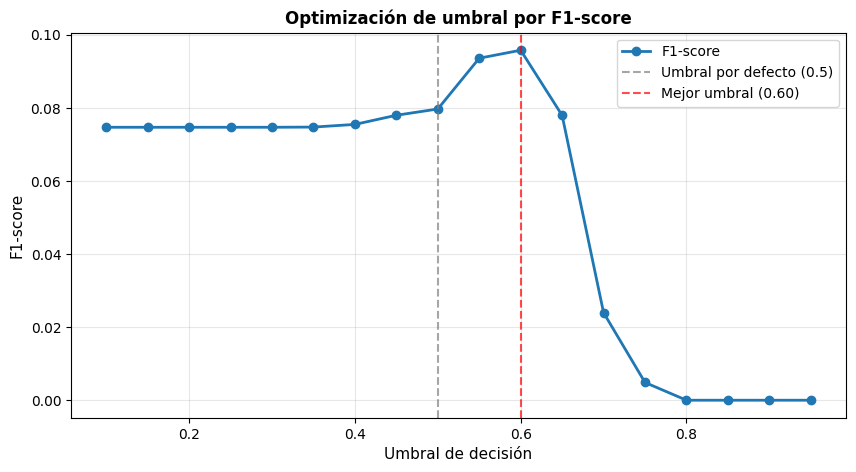

In [106]:
# (OPCIONAL) Ajuste dinámico de umbral para maximizar F1 o recall
print('=== AJUSTE DE UMBRAL ===')
print('Probando diferentes umbrales para encontrar el óptimo...')

mejor_f1 = 0
mejor_umbral = 0.5
f1_scores = []
precision_scores = []
recall_scores = []
umbrales_range = np.arange(0.1, 1.0, 0.05)

for umbral in umbrales_range:
    y_pred_umbral = (y_prob >= umbral).astype(int)
    if y_pred_umbral.sum() > 0:  # Evitar division por cero
        f1_umbral = f1_score(y_true, y_pred_umbral, zero_division=0)
        prec_umbral = precision_score(y_true, y_pred_umbral, zero_division=0)
        rec_umbral = recall_score(y_true, y_pred_umbral, zero_division=0)
        f1_scores.append(f1_umbral)
        precision_scores.append(prec_umbral)
        recall_scores.append(rec_umbral)

        if f1_umbral > mejor_f1:
            mejor_f1 = f1_umbral
            mejor_umbral = umbral
    else:
        f1_scores.append(0)
        precision_scores.append(0)
        recall_scores.append(0)

print(f'Mejor umbral según F1-score: {mejor_umbral:.2f}')
print(f'F1-score en ese umbral: {mejor_f1:.4f}')

# Gráfico de F1 vs umbral
plt.figure(figsize=(10, 5))
plt.plot(umbrales_range, f1_scores, marker='o', linestyle='-', linewidth=2, label='F1-score', markersize=6)
plt.axvline(0.5, color='gray', linestyle='--', linewidth=1.5, alpha=0.7, label='Umbral por defecto (0.5)')
plt.axvline(mejor_umbral, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label=f'Mejor umbral ({mejor_umbral:.2f})')
plt.xlabel('Umbral de decisión', fontsize=11)
plt.ylabel('F1-score', fontsize=11)
plt.title('Optimización de umbral por F1-score', fontsize=12, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.show()